<a href="https://colab.research.google.com/github/Dulina77/Student_Performance_Prediction/blob/main/Student_Performance_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
data = pd.read_csv('student_dataset_10000_rows.csv')

In [20]:
data.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


In [21]:
data.describe()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,5.989600,69.88460,6.498500,6.062600,9.988400,64.91100,86.704207
std,3.163589,17.61653,1.709354,3.138163,6.034145,17.50302,15.058383
min,1.000000,40.00000,4.000000,1.000000,0.000000,35.00000,26.670000
25%,3.000000,55.00000,5.000000,3.000000,5.000000,50.00000,76.727500
50%,6.000000,70.00000,6.500000,6.000000,10.000000,65.00000,92.120000
75%,9.000000,85.00000,8.000000,9.000000,15.000000,80.00000,100.000000
max,11.000000,100.00000,9.000000,11.000000,20.000000,95.00000,100.000000


In [22]:
data.dtypes

,0
study_hours,int64
attendance,int64
sleep_hours,int64
internet_usage,int64
assignments_completed,int64
previous_score,int64
exam_score,float64
placement_status,object


In [23]:
data.isna().sum()

,0
study_hours,0
attendance,0
sleep_hours,0
internet_usage,0
assignments_completed,0
previous_score,0
exam_score,0
placement_status,0


In [24]:
data_duplicated = data[data.duplicated()]
data_duplicated

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status


Outlier Handling

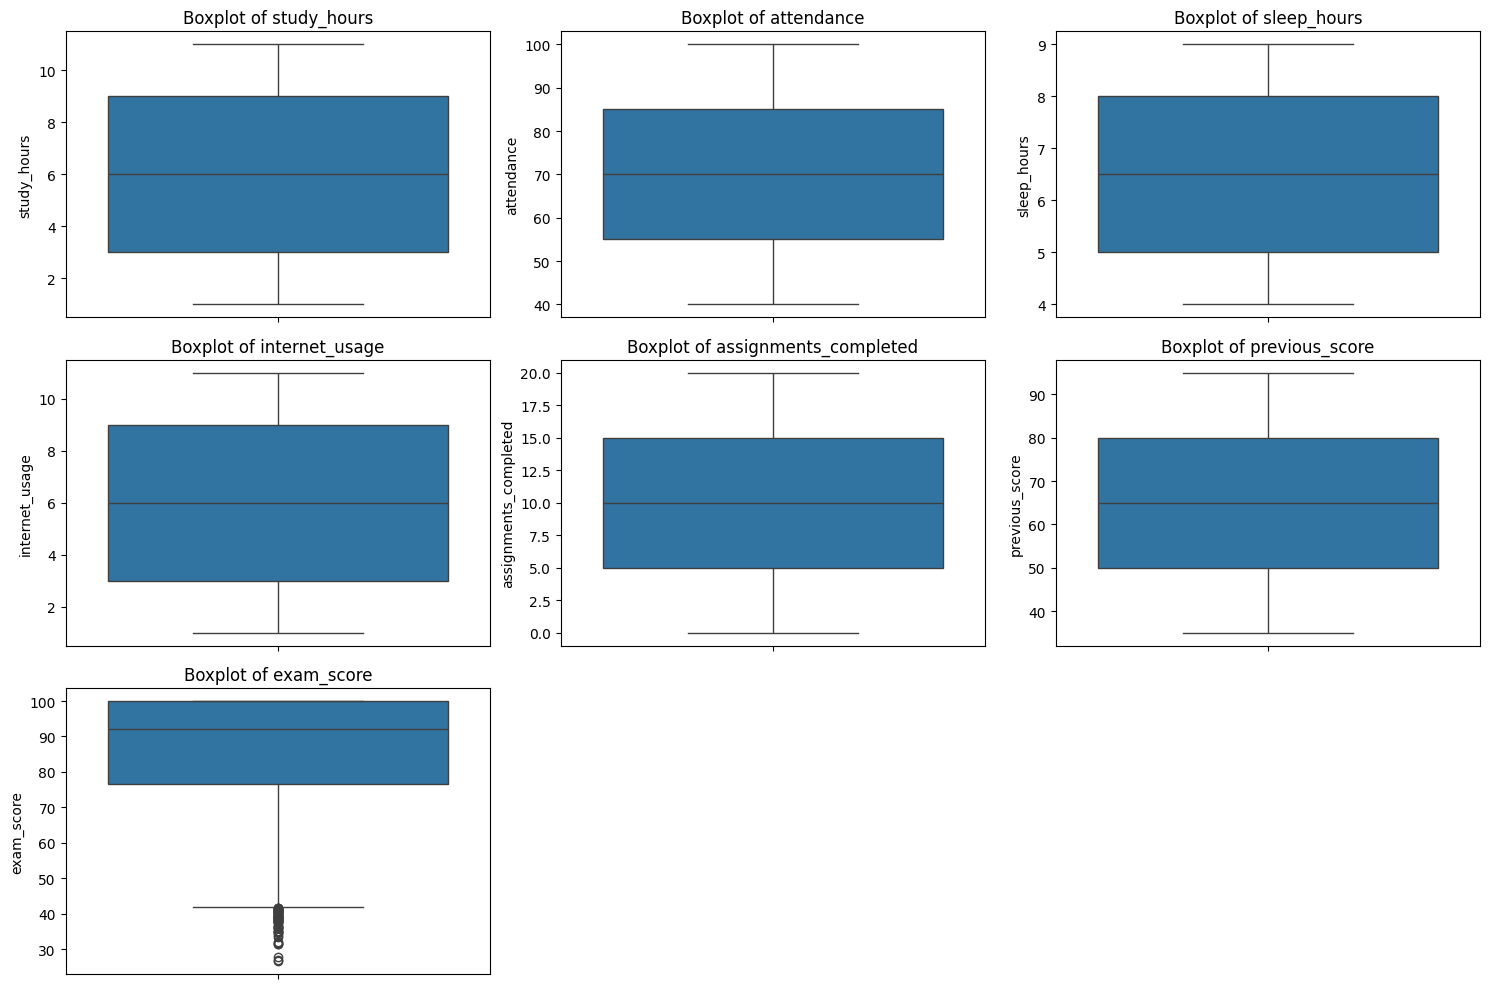

In [25]:
numerical_data = data.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))

for i, column_name in enumerate(numerical_data):
    plt.subplot(3,3,i+1)
    sns.boxplot(y = data[column_name])
    plt.title(f'Boxplot of {column_name}')
plt.tight_layout()
plt.show()


Handling the Outliers - Clipping

In [26]:
df = data.copy()

iqr = df['exam_score'].quantile(0.75) - df['exam_score'].quantile(0.25)

lower_bound = df['exam_score'].quantile(0.25) - (1.5 * iqr)
upper_bound = df['exam_score'].quantile(0.75) + (1.5 * iqr)

non_outliers = df['exam_score'].between(lower_bound, upper_bound)

df = df.loc[non_outliers]

Outlier Handled data

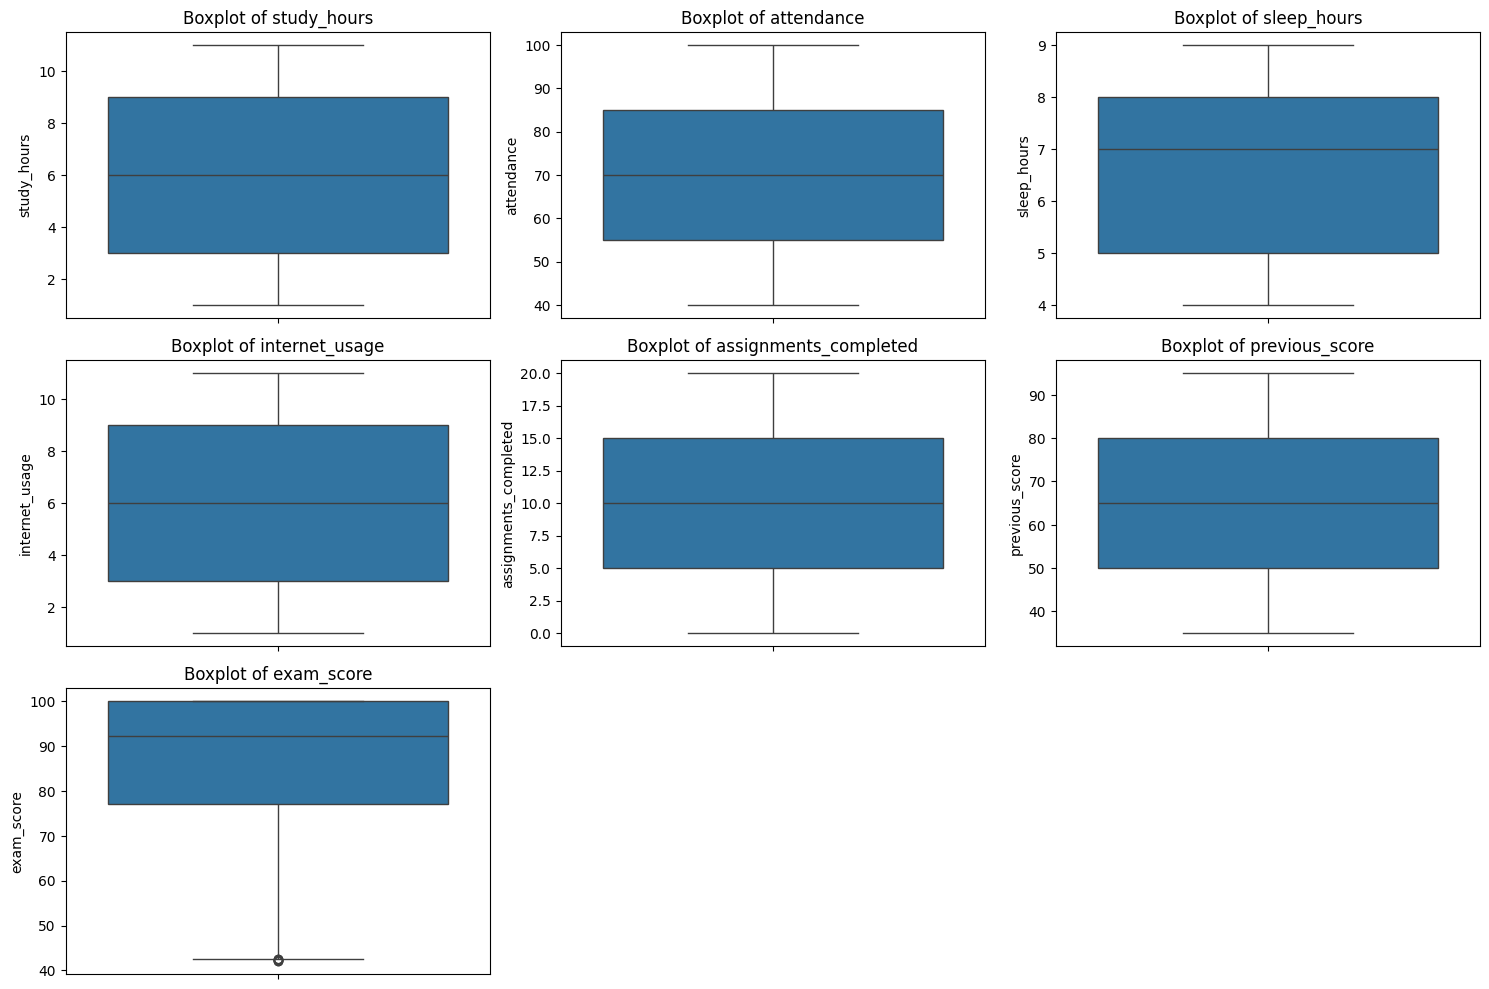

In [27]:
numerical_data_upd = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))

for i, column_name in enumerate(numerical_data):
    plt.subplot(3,3,i+1)
    sns.boxplot(y = df[column_name])
    plt.title(f'Boxplot of {column_name}')
plt.tight_layout()
plt.show()

In [28]:
data = df

In [29]:
data.columns

Index(['study_hours', 'attendance', 'sleep_hours', 'internet_usage',
       'assignments_completed', 'previous_score', 'exam_score',
       'placement_status'],
      dtype='object')

Train Test Split

In [30]:
from sklearn.model_selection import train_test_split

X = data.drop(columns = ['exam_score', 'placement_status']) # Drop both target and categorical string column
y = data['exam_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Scaling the Data

In [31]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


Model Training - Linear Regression

In [32]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)
print(model.score(X_test_scaled, y_test))

0.6543461993052462


In [33]:
y_pred = model.predict(X_test_scaled)

Evaluation

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')

Mean Absolute Error: 6.926858520698674
Mean Squared Error: 74.997661318917
Root Mean Squared Error: 8.660119012976496


Model Training - Random Forest Regression

In [35]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print(rf_model.score(X_test, y_test))

0.681593832460205


In [36]:
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print(f'Mean Absolute Error: {mae_rf}')
print(f'Mean Squared Error: {mse_rf}')
print(f'Root Mean Squared Error: {rmse_rf}')



Mean Absolute Error: 6.019692660127432
Mean Squared Error: 69.08565121230076
Root Mean Squared Error: 8.311777861101724
